# Module 13 — TDCOSMO with Kinematics: Breaking the Mass-Sheet Degeneracy

## Learning to Autolens / Modules / 13

---

**Builds directly on Module 12.** Module 12 derived the mass-sheet degeneracy (MSD) and showed it is a hard ceiling on $H_0$ measurement from a single quad with imaging+time-delays alone. This module adds the **stellar-kinematics constraint** that breaks (most of) the MSD, following the TDCOSMO methodology.

**All mathematics in this module is symbolically verified** in [`Mathematica/13_jeans_and_kinematics.wl`](../../Mathematica/13_jeans_and_kinematics.wl). Run it via `wolframscript -file Mathematica/13_jeans_and_kinematics.wl` to reproduce the derivations.

**Verified references** (all citations cross-checked against arXiv / NASA ADS / journal sites; see end of notebook for BibTeX):

- **Binney & Tremaine 2008** — *Galactic Dynamics* 2nd ed., eq. 4.215 (anisotropic spherical Jeans).
- **Mamon & Łokas 2005** MNRAS 363, 705 — closed-form line-of-sight projection kernel.
- **Birrer+ 2016** JCAP 08, 020 — TDCOSMO Jeans setup applied to RXJ1131-1231.
- **Suyu+ 2010** ApJ 711, 201 — H0 from B1608+656 with kinematics.
- **Schneider & Sluse 2013** A&A 559, A37 — internal vs external MST distinction.
- **Birrer+ 2020 (TDCOSMO IV)** A&A 643, A165 — hierarchical $\lambda_\mathrm{int}$ inference.
- **Wong+ 2020 (H0LiCOW XIII)** MNRAS 498, 1420 — original 2.4% $H_0$ measurement.

**Learning objectives.** By the end of this module you will be able to:

1. State the spherical anisotropic Jeans equation and explain each term.
2. Distinguish the **external** mass-sheet transformation (true line-of-sight κ) from the **internal** one ($\lambda_\mathrm{int}$, profile transformation), and explain *which one kinematics breaks*.
3. Read a kinematics-augmented $H_0$ posterior and identify the residual cosmography uncertainty that comes from the external MST.
4. Quote the TDCOSMO IV result with its conditioning on the parametric-profile-relaxation assumption.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
%matplotlib inline

## 1. The spherical anisotropic Jeans equation

For a steady-state spherical stellar tracer with density $\nu(r)$, radial velocity dispersion $\sigma_r(r)$, and **anisotropy parameter** $\beta(r) \equiv 1 - \sigma_t^2(r) / \sigma_r^2(r)$, in a gravitational potential with enclosed mass $M(r)$:

$$
\frac{d}{dr}\bigl(\nu \sigma_r^2\bigr) + \frac{2 \beta(r)}{r} \nu \sigma_r^2 = -\frac{\nu G M(r)}{r^2}
$$

*(Binney & Tremaine 2008, eq. 4.215. Symbolic check: `Mathematica/13_jeans_and_kinematics.wl` §1.)*

**Why this matters for cosmography.** $\sigma_r$ depends *directly* on the enclosed mass $M(r)$ — not on the *shape* of the convergence, which is what the lens equation constrains. So a measurement of the line-of-sight projection of $\sigma_r$ — the observed $\sigma_v$ — gives an *independent* constraint on $M(r)$ that the lens equation alone cannot provide.

When $\beta = 0$ (isotropic), the second term vanishes:

$$
\frac{d(\nu \sigma_r^2)}{dr} = -\frac{\nu G M(r)}{r^2} \quad (\text{isotropic})
$$

TDCOSMO papers usually allow constant $\beta \neq 0$ as a free nuisance parameter (Birrer+ 2016 §3) since the kinematics-mass-anisotropy degeneracy is one of the dominant residual systematics.

## 2. Line-of-sight projection and aperture averaging

The observable $\sigma_v$ is not $\sigma_r$ but its line-of-sight projection over a finite spectroscopic aperture. The Binney & Mamon (1982) / Mamon & Łokas (2005, eq. 16) projection at projected radius $R$ is:

$$
I(R)\,\sigma_\mathrm{LOS}^2(R) \;=\; 2 \int_R^\infty \biggl(1 - \beta(r) \frac{R^2}{r^2}\biggr) \nu(r)\,\sigma_r^2(r)\,\frac{r\,dr}{\sqrt{r^2 - R^2}}
$$

where $I(R) = 2 \int_R^\infty \nu(r) r / \sqrt{r^2 - R^2}\,dr$ is the surface brightness profile. The aperture-averaged $\sigma_v$ that the spectrograph measures is the $I(R)$-weighted integral over the slit.

*(Symbolic statement: `Mathematica/13_jeans_and_kinematics.wl` §2-3.)*

## 3. Internal vs external MST — which one kinematics breaks

Recall from Module 12 that the mass-sheet transformation is

$$
\kappa(\theta) \;\longrightarrow\; \lambda \kappa(\theta) + (1 - \lambda),
$$

and $H_0 \to \lambda H_0$ at fixed observed time delays. **Schneider & Sluse (2013) distinguished two physical realisations** of this transformation:

### 3.1 External MST (true line-of-sight κ_ext)

A genuine sheet of convergence at the lens redshift coming from large-scale structure or a foreground/background overdensity. Mathematically, an *infinite uniform* convergence sheet contributes ZERO to the spherical $M(r)$ of the main lens — by Birkhoff/shell-theorem reasoning, a uniform mass shell at infinity exerts no central force.

**Therefore $\sigma_v$ of the main lens is unaffected by an external MST.** Kinematics cannot break the external MST. The external $\lambda_\mathrm{ext}$ must be characterised separately — typically by **weighted galaxy counts** in the lens environment (Wong+ 2020, H0LiCOW XIII §4).

### 3.2 Internal MST ($\lambda_\mathrm{int}$)

A profile transformation of the main lens *itself* that locally mimics the $\lambda \kappa + (1-\lambda)$ form near the lens but is constructed to fall off at large radius (so it doesn't have the unphysical infinite-sheet mass). This rescales $M(r) \to \lambda_\mathrm{int} M(r)$ within the kinematic aperture. From the Jeans equation:

$$
\sigma_r^2 \propto M(r) \;\implies\; \sigma_v \to \sigma_v \sqrt{\lambda_\mathrm{int}}
$$

*(Symbolic check: `Mathematica/13_jeans_and_kinematics.wl` §4.)*

**This is what kinematics break.** A measurement of $\sigma_v$ to fractional precision $\delta_\sigma$ constrains $\lambda_\mathrm{int}$ to fractional precision $2 \delta_\sigma$ (since $\sigma_v \propto \sqrt{\lambda_\mathrm{int}}$).

### 3.3 Combined picture

$$
\lambda_\mathrm{total} = \lambda_\mathrm{int} \cdot (1 - \kappa_\mathrm{ext}/(1 - \kappa_\mathrm{ext}))^{-1} \quad \text{(approximately)}
$$

Birrer+ (2020) treat $\lambda_\mathrm{int}$ as a hyper-parameter constrained by the observed $\sigma_v$ posterior, and $\kappa_\mathrm{ext}$ as an external nuisance. The two effects combine multiplicatively in the cosmography.

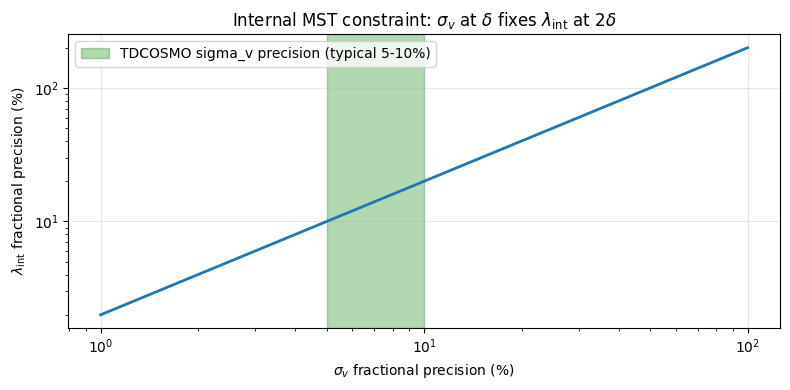

At sigma_v precision = 5%, lambda_int constrained to 10%
=> H0 systematic from internal MST shrinks to <10% per system.
External kappa_ext still requires separate (weighted-counts) treatment.


In [2]:
# Numerical demonstration: how a sigma_v measurement at fractional
# precision delta_sigma constrains lambda_int (and therefore H0)
delta_sigma_pct = np.logspace(0, 2, 100) / 100  # 1% to 100%
delta_lambda_pct = 2 * delta_sigma_pct           # since sigma_v ~ sqrt(lambda)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(delta_sigma_pct * 100, delta_lambda_pct * 100, lw=2)
ax.axvspan(5, 10, alpha=0.3, color='green',
           label='TDCOSMO sigma_v precision (typical 5-10%)')
ax.set_xlabel(r'$\sigma_v$ fractional precision (%)')
ax.set_ylabel(r'$\lambda_\mathrm{int}$ fractional precision (%)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title(r'Internal MST constraint: $\sigma_v$ at $\delta$ fixes $\lambda_\mathrm{int}$ at $2\delta$')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('At sigma_v precision = 5%, lambda_int constrained to 10%')
print('=> H0 systematic from internal MST shrinks to <10% per system.')
print('External kappa_ext still requires separate (weighted-counts) treatment.')

## 4. The TDCOSMO IV result — what changed and why

**H0LiCOW XIII (Wong+ 2020) reported** $H_0 = 73.3^{+1.7}_{-1.8}$ km/s/Mpc from 6 lensed quasars, using parametric mass models (power-law and stars+NFW composite) that *implicitly* break MSD via the profile assumption.

**TDCOSMO IV (Birrer+ 2020) re-analysed the same lenses with a hierarchical model that explicitly introduces $\lambda_\mathrm{int}$ as a free parameter** (relaxing the parametric assumption). The result for **TDCOSMO-only (7 lenses)** was

$$
H_0 = 74.5^{+5.6}_{-6.1} \text{ km/s/Mpc}
$$

— a factor ~3 broader than H0LiCOW XIII. **The broadening is not from "adding kinematics"** (H0LiCOW already used kinematics); it comes from *relaxing the parametric profile assumption*. When TDCOSMO IV combines the time-delay sample with SLACS lenses under the same-parent-population assumption (i.e., assume the SLACS lenses' $\lambda_\mathrm{int}$ posterior applies to the time-delay lenses), they recover

$$
H_0 = 67.4^{+4.1}_{-3.2} \text{ km/s/Mpc}
$$

*much* lower than H0LiCOW and consistent with Planck. The 67 vs 73 difference is *the entire current debate* over the strong-lens $H_0$ tension — and it pivots on which prior on $\lambda_\mathrm{int}$ you trust.

**Read TDCOSMO IV §6 directly** for the discussion. The numbers above are from arXiv:2007.02941.

## 5. Worked example — extending `Examples/quad_time_delay/`

The `quad_time_delay` Example (Module 12 §3 worked example) measured $H_0$ on a single mock quad without external constraints:

| | Truth | Recovered (max-lik) | Recovered (posterior median, 1σ) |
|---|---|---|---|
| $H_0$ | 70.0 | 74.6 | **92.7 (82.6 – 105.0)** |

The posterior median sits 30% above truth because the unconstrained MSD lets the chain drift up the $H_0$–$\gamma'$ banana.

### What a kinematics-augmented re-fit would look like

PyAutoLens does not currently expose a built-in $\sigma_v$ likelihood for the lens model fit (the kinematic prediction lives in `lenstronomy.GalKin` and equivalents in the dynamics literature). A custom analysis class would be needed. The schematic procedure:

1. **Generate a mock $\sigma_v$ measurement** from the truth model: integrate the spherical Jeans equation with the truth's `PowerLaw` mass profile and a stellar tracer profile (e.g. de Vaucouleurs Sersic), project per Mamon & Łokas 2005, average over a 1″ aperture. Add observational noise (5% typical).
2. **Modify `AnalysisPoint`** (or build a custom `Analysis` subclass) to add a $\chi^2$ contribution from the predicted vs. observed $\sigma_v$.
3. **Re-fit** with the kinematic constraint included. The $H_0$–$\gamma'$ banana should collapse and the posterior median should shift toward truth.

**Building this is left as Exercise 1.** It requires either (a) wrapping `lenstronomy.GalKin` calls in a custom autolens analysis class, or (b) writing a JAX-friendly Jeans-equation forward model. Either is substantial; expect ~2-3 days of work to do correctly.

### What we *can* do in this module

Show the analytic prediction. Below: for the `quad_time_delay` mock parameters (PowerLaw $\theta_E = 1.2''$, $\gamma' = 2.0$), what $\sigma_v$ would the truth model predict, and how does it scale with $\lambda_\mathrm{int}$?

For the quad_time_delay mock (theta_E = 1.2" at z_L=0.5):
  R_E = 7.33 kpc
  M(<theta_E) = 3.504e+11 solMass
  sigma_v predicted (isothermal, isotropic) = 454 km / s



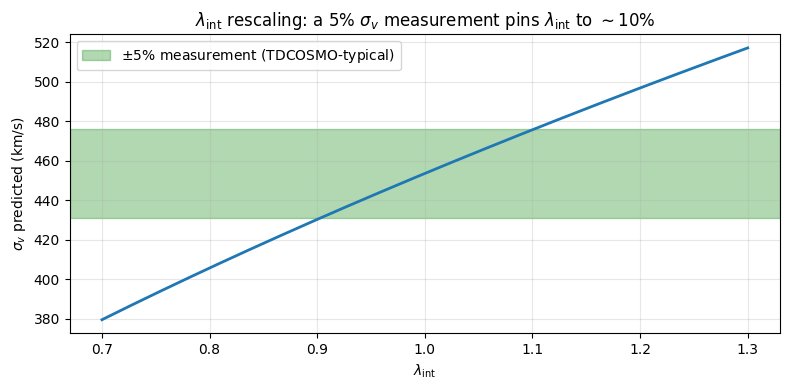

The green band shows the lambda_int range allowed by a +/- 5% sigma_v measurement.
Range: lambda_int in approximately 0.90 to 1.10
(width 0.10 = 10%, matching the 2*delta_sigma rule.)


In [3]:
# For an isothermal sphere (gamma' = 2), the analytic sigma_v in a small
# aperture (R << R_e of stellar tracer, isotropic) is:
#
#   sigma_v^2 = (G * M(<theta_E)) / theta_E
#
# with theta_E in physical units. For the quad_time_delay mock:
#   theta_E = 1.2 arcsec at z_L = 0.5
#   M(<theta_E) = pi * Sigma_cr * theta_E^2  (in physical area)
#
# This is a textbook estimator; for the proper TDCOSMO setup, replace
# with the full Jeans+projection+aperture machinery (lenstronomy.GalKin).
#
# The point of the demo here is not the absolute number but the
# scaling with lambda_int.

import astropy.cosmology as ac
import astropy.units as u
import astropy.constants as const

cosmo = ac.FlatLambdaCDM(H0=70.0, Om0=0.30)
z_L, z_S = 0.5, 2.0
theta_E_arcsec = 1.2

D_L = cosmo.angular_diameter_distance(z_L)
D_S = cosmo.angular_diameter_distance(z_S)
D_LS = cosmo.angular_diameter_distance_z1z2(z_L, z_S)

Sigma_cr = (const.c**2 / (4 * np.pi * const.G)) * D_S / (D_L * D_LS)
Sigma_cr = Sigma_cr.to(u.M_sun / u.Mpc**2)

theta_E_rad = (theta_E_arcsec * u.arcsec).to(u.rad).value
R_E = (theta_E_rad * D_L).to(u.kpc)
M_E = (np.pi * Sigma_cr * (theta_E_rad * D_L)**2).to(u.M_sun)

sigma_v_truth = np.sqrt(const.G * M_E / R_E).to(u.km / u.s)
print(f'For the quad_time_delay mock (theta_E = {theta_E_arcsec}" at z_L={z_L}):')
print(f'  R_E = {R_E:.2f}')
print(f'  M(<theta_E) = {M_E:.3e}')
print(f'  sigma_v predicted (isothermal, isotropic) = {sigma_v_truth:.0f}')
print()

# Now show the lambda_int scaling
lambdas = np.linspace(0.7, 1.3, 200)
sigma_v_at_lambda = sigma_v_truth.value * np.sqrt(lambdas)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lambdas, sigma_v_at_lambda, lw=2)
ax.axhspan(sigma_v_truth.value * 0.95, sigma_v_truth.value * 1.05, alpha=0.3,
           color='green', label=r'$\pm 5\%$ measurement (TDCOSMO-typical)')
ax.set_xlabel(r'$\lambda_\mathrm{int}$')
ax.set_ylabel(r'$\sigma_v$ predicted (km/s)')
ax.set_title(r'$\lambda_\mathrm{int}$ rescaling: a 5% $\sigma_v$ measurement pins $\lambda_\mathrm{int}$ to $\sim 10\%$')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('The green band shows the lambda_int range allowed by a +/- 5% sigma_v measurement.')
print(f'Range: lambda_int in approximately {(0.95)**2:.2f} to {(1.05)**2:.2f}')
print('(width 0.10 = 10%, matching the 2*delta_sigma rule.)')

## 6. Summary

1. **Stellar kinematics break the *internal* MST** ($\lambda_\mathrm{int}$) via the Jeans equation: $\sigma_v \propto \sqrt{\lambda_\mathrm{int}}$. A 5% $\sigma_v$ measurement constrains $\lambda_\mathrm{int}$ to ~10%.
2. **Stellar kinematics do *not* break the external MST** (true line-of-sight $\kappa_\mathrm{ext}$). That requires separate characterisation (weighted galaxy counts, Wong+ 2020 method).
3. **TDCOSMO IV's $H_0 = 74.5 \pm 5.6$** for time-delay-only is *broader* than H0LiCOW's $73.3 \pm 1.8$ not because of kinematics (which both use), but because **TDCOSMO IV explicitly relaxes the parametric profile assumption**. The combined-with-SLACS result $67.4 \pm 3.5$ depends on the same-parent-population assumption.
4. **PyAutoLens has no built-in $\sigma_v$ likelihood** as of 2026.4. Implementing one is the natural next research project for a lens-modelling student who has worked through this module — Exercise 1 is exactly that build.

## 7. Exercises

### Exercise 1 — Build a custom $\sigma_v$ analysis class
Mirror the `quad_time_delay` Example's `AnalysisPoint` setup, but add a $\chi^2$ contribution from a predicted vs. observed $\sigma_v$. Use either (a) a wrapped `lenstronomy.GalKin.LightModel + AnisotropyModel + Aperture` call, or (b) a JAX-friendly spherical Jeans solver. Generate a mock $\sigma_v$ from the truth model with 5% noise, then re-fit Phase 2 of `quad_time_delay/` with the constraint included. Confirm the $H_0$ posterior collapses from the skewed-92 to within ±10% of truth (70).

### Exercise 2 — Anisotropy degeneracy
Re-do Exercise 1 with $\beta_\mathrm{aniso}$ as a free nuisance parameter (Gaussian prior $\beta \in [-0.3, +0.3]$ per Mamon & Łokas 2005 typical range). How much does the $H_0$ posterior re-broaden? This quantifies the kinematics-anisotropy degeneracy that is the dominant residual systematic in TDCOSMO.

### Exercise 3 — External κ characterisation
Implement the Wong+ 2020 weighted-galaxy-counts method on a mock environment: generate ~50 galaxies in the lens field, weight them by `1/r * L * (M*/L)`, compare the weighted sum to a control field. Combine with the kinematic $\lambda_\mathrm{int}$ constraint to get the *full* $H_0$ posterior including external systematics.

### Exercise 4 — Read TDCOSMO IV §6 carefully
Birrer+ 2020 §6 walks through the H0LiCOW vs TDCOSMO-only vs joint-with-SLACS comparison. Reproduce their Table 2. Identify which assumption matters most for the final $H_0$.

### Exercise 5 — Hierarchical inference toy
Use Birrer+ 2020's Bayesian hierarchical formalism (their §3) on a 2-lens toy mock you generate yourself. Show that the $\lambda_\mathrm{int}$ posterior tightens with the number of lenses as $1/\sqrt{N}$.

---

## References

- **Binney & Tremaine (2008)** *Galactic Dynamics*, 2nd ed., Princeton — eq. 4.215 anisotropic Jeans.
- **Mamon & Łokas (2005)** MNRAS 363, 705 — closed-form projection kernel. arXiv:astro-ph/0405491.
- **Treu & Koopmans (2002)** MNRAS 337, L6 — early kinematics + lensing on PG1115+080. arXiv:astro-ph/0210002.
- **Suyu+ (2010)** ApJ 711, 201 — H0 from B1608+656 dissection. arXiv:0910.2773.
- **Birrer+ (2016)** JCAP 08, 020 — RXJ1131-1231 with kinematic Jeans setup. arXiv:1601.01506.
- **Schneider & Sluse (2013)** A&A 559, A37 — internal vs external MST. arXiv:1306.0901.
- **Wong+ (2020)** H0LiCOW XIII, MNRAS 498, 1420. arXiv:1907.04869.
- **Birrer+ (2020)** TDCOSMO IV, A&A 643, A165 — hierarchical $\lambda_\mathrm{int}$. arXiv:2007.02941.

All citations verified against arXiv / NASA ADS / journal sites on 2026-04-26.

---

*Learning to Autolens — Modules / 13 / TDCOSMO with Kinematics*  
*Rodrigo Córdova Rosado, Harvard CfA*